In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [45]:
path = r'Data/real_data_set.csv'

In [46]:
df = pd.read_csv(path)

In [47]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [49]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [50]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [51]:
df['Teacher_Quality'] = df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0])
df['Parental_Education_Level'] = df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0])
df['Distance_from_Home'] = df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0])

In [52]:
df.duplicated().sum()

np.int64(0)

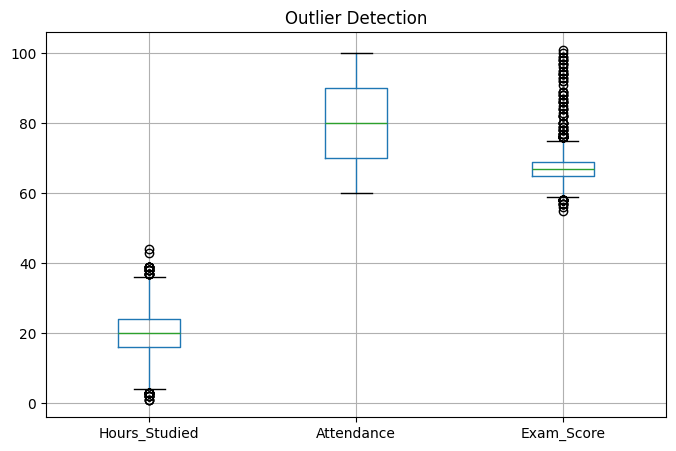

In [53]:
plt.figure(figsize=(8,5))
df.boxplot(column=['Hours_Studied', 'Attendance', 'Exam_Score'])
plt.title('Outlier Detection')
plt.show()

In [54]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [55]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_columns = [
    'Parental_Involvement',
    'Access_to_Resources',
    'Motivation_Level',
    'Teacher_Quality',
    'Family_Income'
]

ordinal_columns1 = [
    'Peer_Influence'
]

encoder = OrdinalEncoder(
    categories=[['Low', 'Medium', 'High']] * len(ordinal_columns)
)

df[ordinal_columns] = encoder.fit_transform(df[ordinal_columns])


encoder = OrdinalEncoder(
    categories=[['Negative', 'Neutral', 'Positive']]
)

df[ordinal_columns1] = encoder.fit_transform(df[ordinal_columns1])

In [56]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0.0,2.0,No,7,73,0.0,Yes,0,0.0,1.0,Public,2.0,3,No,High School,Near,Male,67
1,19,64,0.0,1.0,No,8,59,0.0,Yes,2,1.0,1.0,Public,0.0,4,No,College,Moderate,Female,61
2,24,98,1.0,1.0,Yes,7,91,1.0,Yes,2,1.0,1.0,Public,1.0,4,No,Postgraduate,Near,Male,74
3,29,89,0.0,1.0,Yes,8,98,1.0,Yes,1,1.0,1.0,Public,0.0,4,No,High School,Moderate,Male,71
4,19,92,1.0,1.0,Yes,6,65,1.0,Yes,3,1.0,2.0,Public,1.0,4,No,College,Near,Female,70


In [57]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

columns = [
    'Extracurricular_Activities',
    'Internet_Access',
    'Learning_Disabilities',
    'Gender'
]

for column_name in columns:
    df[column_name] = encoder.fit_transform(df[column_name])

In [58]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,0.0,2.0,0,7,73,0.0,1,0,0.0,1.0,Public,2.0,3,0,High School,Near,1,67
1,19,64,0.0,1.0,0,8,59,0.0,1,2,1.0,1.0,Public,0.0,4,0,College,Moderate,0,61
2,24,98,1.0,1.0,1,7,91,1.0,1,2,1.0,1.0,Public,1.0,4,0,Postgraduate,Near,1,74
3,29,89,0.0,1.0,1,8,98,1.0,1,1,1.0,1.0,Public,0.0,4,0,High School,Moderate,1,71
4,19,92,1.0,1.0,1,6,65,1.0,1,3,1.0,2.0,Public,1.0,4,0,College,Near,0,70


In [59]:
from sklearn.preprocessing import OneHotEncoder

columns = [
    'School_Type',
    'Parental_Education_Level',
    'Distance_from_Home'
]

encoder = OneHotEncoder(sparse_output=False, drop='first')

encoded_data = encoder.fit_transform(df[columns])

encoded_df = pd.DataFrame(data=encoded_data, columns=encoder.get_feature_names_out(columns))

df = df.drop(columns, axis=1)
df = pd.concat([df, encoded_df], axis=1)

In [60]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Peer_Influence,Physical_Activity,Learning_Disabilities,Gender,Exam_Score,School_Type_Public,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near
0,23,84,0.0,2.0,0,7,73,0.0,1,0,...,2.0,3,0,1,67,1.0,1.0,0.0,0.0,1.0
1,19,64,0.0,1.0,0,8,59,0.0,1,2,...,0.0,4,0,0,61,1.0,0.0,0.0,1.0,0.0
2,24,98,1.0,1.0,1,7,91,1.0,1,2,...,1.0,4,0,1,74,1.0,0.0,1.0,0.0,1.0
3,29,89,0.0,1.0,1,8,98,1.0,1,1,...,0.0,4,0,1,71,1.0,1.0,0.0,1.0,0.0
4,19,92,1.0,1.0,1,6,65,1.0,1,3,...,1.0,4,0,0,70,1.0,0.0,0.0,0.0,1.0


In [61]:
df['Scholarship_Score'] = (
    df['Exam_Score'] * 0.6 +
    df['Attendance'] * 0.2 +
    df['Hours_Studied'] * 0.5 +
    df['Motivation_Level'] * 5 +
    (2 - df['Family_Income']) * 5 +
    df['Parental_Involvement'] * 5
)

df['Scholarship_Score'] = (
    (df['Scholarship_Score'] / df['Scholarship_Score'].max()) * 100
)

In [62]:
df.describe()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Physical_Activity,Learning_Disabilities,Gender,Exam_Score,School_Type_Public,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Scholarship_Score
count,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000,...,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,1.086423,1.100197,0.596035,7.02906,75.070531,0.906463,0.924474,1.493719,...,2.967610,0.105191,0.577267,67.235659,0.695929,0.501438,0.197518,0.302407,0.598002,72.941306
std,5.990594,11.547475,0.695521,0.698347,0.490728,1.46812,14.399784,0.695798,0.264258,1.230570,...,1.031231,0.306823,0.494031,3.890456,0.460048,0.500036,0.398156,0.459335,0.490339,7.447169
min,1.000000,60.000000,0.000000,0.000000,0.000000,4.00000,50.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,47.918512
25%,16.000000,70.000000,1.000000,1.000000,0.000000,6.00000,63.000000,0.000000,1.000000,1.000000,...,2.000000,0.000000,0.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.847653
50%,20.000000,80.000000,1.000000,1.000000,1.000000,7.00000,75.000000,1.000000,1.000000,1.000000,...,3.000000,0.000000,1.000000,67.000000,1.000000,1.000000,0.000000,0.000000,1.000000,72.896368
75%,24.000000,90.000000,2.000000,2.000000,1.000000,8.00000,88.000000,1.000000,1.000000,2.000000,...,4.000000,0.000000,1.000000,69.000000,1.000000,1.000000,0.000000,1.000000,1.000000,78.033658
max,44.000000,100.000000,2.000000,2.000000,1.000000,10.00000,100.000000,2.000000,1.000000,8.000000,...,6.000000,1.000000,1.000000,101.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.000000


In [63]:
df['Grant_Eligible'] = np.where(
    df['Scholarship_Score'] > 70,
    1,
    0
)

In [64]:
df['Grant_Eligible'].value_counts()

Grant_Eligible
1    4286
0    2321
Name: count, dtype: int64

In [65]:
def assign_grant(score):

    if score >= 95:
        return 100

    elif score >= 90:
        return 95

    elif score >= 85:
        return 90

    elif score >= 80:
        return 85

    elif score >= 75:
        return 80

    elif score >= 70:
        return 75

    else:
        return 0

In [66]:
df['Grant_Percent'] = df['Scholarship_Score'].apply(assign_grant)

df['Grant_Amount'] = (
    df['Grant_Percent'] / 100
) * 39000000

df['Grant_Amount'] = df['Grant_Amount'].astype(int)

In [67]:
df.to_csv('Data/train_dataset.csv', index=False)